# Demo 07: Fine-tune EpiZoo for peak prediction

This notebook demonstrates how to fine-tune **EpiZoo** and get **EpiZooSeq** for peak accessibility prediction.

Starting from a pretrained EpiZoo model, users can fine-tune the model to predict accessibility of each peak.

## Required files

Before running this notebook, please prepare the following files:

- **`model.pth`**: The pretrained EpiZoo model checkpoint. (The pretrained EpiZoo checkpoint can be downloaded at [pretrained_EpiZoo.pth](https://drive.google.com/file/d/1Xs5R_LAMbB_Zqpg7SFHlrAMfVcdcGwVE/view?usp=drive_link))
- **`seam.pth`**: SEAM checkpoint. (The SEAM checkpoint can be downloaded at [SEAM.pth](https://drive.google.com/file/d/1VlPnwrvMxkvKkqEOvM_pciCwJH5Jgb8Y/view?usp=drive_link))
- **`adata.h5ad`**: The scATAC-seq data. (The demo data can be downloaded at [biccn_downsampled_2000_cells.h5ad](https://drive.google.com/file/d/1g-A47AxxP4BbU1hXxKCRE8aTJOA8DepO/view?usp=drive_link))
- **`genome.fa`**: The reference genome sequence file

## Output

This notebook will generate:

- Fine-tuned EpiZooSeq model checkpoint
- Predicted peak accessibility

In [1]:
import os
import sys

# Add EpiZoo root directory
PROJECT_ROOT = os.path.abspath("../")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

## Step 1: Compute cell embeddings using the pretrained/fine-tuned EpiZoo

We first compute cell embeddings using EpiZoo. Users can either use the pretrained EpiZoo model or fine-tune the model on the target dataset. Please refer to `02_finetune_epizoo.ipynb` for the fine-tuning workflow.

In [2]:
import scanpy as sc
import numpy as np
import pandas as pd

from epizoo.data.processing import compute_tfidf, filter_cCREs, generate_cell_sentences

# 1. Load required data files
# Load the dataset
adata_file_path = "../data/biccn_downsampled_2000_cells.h5ad"
adata = sc.read_h5ad(adata_file_path)
print(f"Anndata: {adata}")

# Load the cCRE document frequency data (for mouse here)
df_file_path = "../data/cCRE_frequencies_mouse.npy"
df = np.load(df_file_path)
print(f"Document Frequency: {df}")

# Load the cCRE filter index (for mouse here)
filter_index_file_path = "../data/cCRE_filter_idx_mouse.csv"
filter_index = pd.read_csv(filter_index_file_path,index_col=0)['idx'].values
print(f"Filter Index: {filter_index}")

# 2. Preprocess the data
# Perform TF-IDF transformation
adata = compute_tfidf(adata, df, cell_number=12500000)

# Filter cCRE
adata = filter_cCREs(adata, filter_idx=filter_index, species=1)

# Generate cell sentences
adata = generate_cell_sentences(adata, species=1, species_offset=700460)
print(f"Cell Sentences:\n{adata.obs['cell_indices'][:5]}")

/home/jiangqun/miniconda3/envs/cellemu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Anndata: AnnData object with n_obs × n_vars = 2000 × 1341077
    obs: 'orig.ident', 'subclass', 'cell_type_for_CREshet'
Document Frequency: [ 9086. 20040. 10906. ...  1046.  1051.  3763.]
Filter Index: [      3       4       8 ... 1341044 1341059 1341062]
TF-IDF completed. TF-IDF matrix stored in adata.X
Matrix shape: (2000, 1341077)
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Data type: float32
Non-zero entries: 41,663,477
Sparsity: 98.4466%
Non-zero value min: 0.095511
Non-zero value max: 302.659515
Non-zero value mean: 1.868840
Non-zero value median: 1.234956
--------------------------------------------------
Accessible cCREs per cell:
  Mean: 20831.74
  Median: 18157.00
  Min: 543
  Max: 55812
Filtered cCREs: 814020 features retained.
Cell Sentences:
cell
MOp2c1_GCTTACCTCAAAGGCA-1    [942008, 942009, 805641, 726898, 1323018, 1129...
MOp5d2_TTTACGCGTGCGCGTA-1    [851055, 986320, 1449194, 1449196, 1386221, 73...
MOp5d1_AACTACTCATGTGGGA-1    [1192351, 1044021, 1116164, 860259,

In [3]:
from epizoo.data.datasets import InferenceCellDataset, inference_collate_fn
from torch.utils.data import DataLoader

# Create a dataset and dataloader for inference
inference_dataset = InferenceCellDataset(
    cell_sentences=adata.obs['cell_indices'].values,
    species=[1] * adata.n_obs,
)
inference_dataloader = DataLoader(
    inference_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=inference_collate_fn,
)

In [4]:
import torch
from epizoo.models.epizoo import EpiZooConfig, EpiZoo

# Load the model
model_path = "/data/lizhen/epizoo/models/pretrained_EpiZoo.pth"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Initialize EpiZoo model
human_vocab_size = 700460
mouse_vocab_size = 814020
config = EpiZooConfig(
    vocab_size = human_vocab_size + mouse_vocab_size + 4,
    human_vocab_size = human_vocab_size,
    mouse_vocab_size = mouse_vocab_size,
    num_layers = 30,
)
pretrained_model = EpiZoo(cfg=config)

# Load model weights
state_dict = torch.load(model_path, map_location="cpu")
pretrained_model.load_state_dict(state_dict, strict=False)

# Move model to device
pretrained_model = pretrained_model.to(device)
pretrained_model.eval()

print("EpiZoo model loaded successfully.")

EpiZoo model loaded successfully.


In [5]:
from epizoo.inference.embeddings import extract_cell_embeddings

# Extract cell embeddings
cell_embeddings = extract_cell_embeddings(
    pretrained_model,
    inference_dataloader,
    device=device,
)
print(f"Completed. Cell embeddings shape: {cell_embeddings.shape}")

Extracting cell embeddings: 100%|██████████| 32/32 [02:45<00:00,  5.16s/it]

Completed. Cell embeddings shape: (2000, 512)


## Step 2: Compute cell-type embeddings

We generate cell-type embeddings by averaging the cell embeddings of cells within the same cell type.

In [6]:
# cell type labels
cell_types = adata.obs["cell_type_for_CREshet"].values

# Compute cell-type embeddings
celltype_embeddings = {}
for cell_type in sorted(np.unique(cell_types)):
    mask = cell_types == cell_type
    celltype_embeddings[cell_type] = cell_embeddings[mask].mean(axis=0)

# Convert to matrix
celltype_names = list(celltype_embeddings.keys())
celltype_embeddings = np.vstack(
    [celltype_embeddings[x] for x in celltype_names]
)

print("Cell-type embeddings:", celltype_embeddings.shape)
print("Number of cell types:", len(celltype_names))

Cell-type embeddings: (19, 512)
Number of cell types: 19


## Step 3: Create Dataset and DataLoader

We construct `SEAMDataset` and DataLoader for model training. `signals` should by provided for EpiZooSeq.

In [7]:
from epizoo.data.ccre import extract_dna_sequences

adata_peak_file_path = "../data/biccn_cell_type_downsampled_50000_peaks.h5ad"
adata_peak = sc.read_h5ad(adata_peak_file_path)
print(f"Anndata: {adata_peak}")

# Split train and test datasets
adata_peak_train = adata_peak[:,adata_peak.var['split'] == 'train'].copy()
adata_peak_test = adata_peak[:,adata_peak.var['split'] == 'test'].copy()

# Get the sequences
genome_file_path = "/data/lizhen/epizoo/genomes_fa/mm10.fa"
train_regions = adata_peak_train.var_names.tolist()
train_sequences = extract_dna_sequences(fasta_path=genome_file_path, regions=train_regions)
test_regions = adata_peak_test.var_names.tolist()
test_sequences = extract_dna_sequences(fasta_path=genome_file_path, regions=test_regions)

Anndata: AnnData object with n_obs × n_vars = 19 × 50000
    obs: 'file_path'
    var: 'chr', 'start', 'end', 'split'
    obsm: 'weights'
    layers: 'DeepBICCN2', 'DeepBICCN2_base', 'gReLU_22M', 'gReLU_6M'


Extracting DNA sequences: 100%|██████████| 4626/4626 [00:00<00:00, 25921.76it/s]


In [8]:
from epizoo.data.datasets import SEAMDataset, collate_fn_seam

# Create SEAMDataset and dataloader
train_dataset = SEAMDataset(
    sequences=train_sequences,
    cfg_path="../config/SEAM_config",
    signals=adata_peak_train.X.T,
)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=False,
    collate_fn=collate_fn_seam,
)

test_dataset = SEAMDataset(
    sequences=test_sequences,
    cfg_path="../config/SEAM_config",
    signals=adata_peak_test.X.T,
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    collate_fn=collate_fn_seam,
)

## Step 4: Model initialization

We initialize the EpiZooSeq model using the cell-type embeddings and pretrained SEAM parameters.

In [9]:
from epizoo.models.epizoo_seq import EpiZooSeqConfig, EpiZooSeq

# Initialize EpiZooSeq model
config = EpiZooSeqConfig(cfg_path='../config/SEAM_config')
model = EpiZooSeq(
    cell_type_emb=celltype_embeddings,
    cfg=config,
)

# Load the pretrained SEAM
model_path = "/data/lizhen/epizoo/models/seam.pth"
state_dict = torch.load(model_path, map_location="cpu")
model.seam.load_state_dict(state_dict)
model = model.to(device)

print("EpiZooSeq model loaded successfully.")

EpiZooSeq model loaded successfully.


## Step 5: Model training

We train the EpiZooSeq model using `EpiZooSeqTrainer`.

The model checkpoint will be saved for downstream inference.

In [10]:
from epizoo.train.seq import EpiZooSeqTrainer, EpiZooSeqTrainConfig

# Post-training configuration
cfg = EpiZooSeqTrainConfig(
    output_dir="/data/lizhen/epizoo/models/model_seq",
    epochs=3,
    warmup_epochs=1,
    lr_head_warmup=1e-4,
    lr_head=1e-4,
    lr_backbone=1e-5,
    logging_steps=200,
    save_epochs=1,
    keep_last=2,
    warmup_ratio_phase1=0.1,
    warmup_ratio_phase2=0.2,
    device=device,
)

trainer = EpiZooSeqTrainer(
    model=model,
    train_loader=train_dataloader,
    cfg=cfg,
)

# Start training
trained_model = trainer.train()

print(
    "This demo demonstrates the training workflow only. "
    "In practice, sufficient training steps are required."
)

Epoch 1: phase 1. Frozen SEAM backbone.


Epoch 1/3:   0%|          | 0/315 [00:00<?, ?it/s]/home/jiangqun/miniconda3/envs/cellemu/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
Epoch 1/3:  63%|██████▎   | 200/315 [01:16<00:48,  2.38it/s, loss=2.5584, lr=3.53e-05]

Epoch 1 | Step 200 | loss=2.2650 | lr=3.529e-05


Epoch 1/3: 100%|██████████| 315/315 [01:59<00:00,  2.63it/s, loss=3.9304, lr=0.00e+00]


Epoch 1 finished | train_loss=2.1002
Checkpoint saved to /data/lizhen/epizoo/models/model_seq/epoch_1.pth
Epoch 2: phase 2. Unfrozen SEAM backbone.


...

Epoch 2 finished | train_loss=1.4884
Checkpoint saved to /data/lizhen/epizoo/models/model_seq/epoch_2.pth


Epoch 3/3:  54%|█████▍    | 170/315 [02:29<02:10,  1.11it/s, loss=0.5334, lr=1.91e-05]

Epoch 3 | Step 800 | loss=1.3392 | lr=1.907e-05


Epoch 3/3: 100%|██████████| 315/315 [04:33<00:00,  1.15it/s, loss=3.0803, lr=0.00e+00]


Epoch 3 finished | train_loss=1.3277
Checkpoint saved to /data/lizhen/epizoo/models/model_seq/epoch_3.pth
EpiZooSeq training finished.
This demo demonstrates the training workflow only. In practice, sufficient training steps are required.


## Step 5: Predict peak signals on test dataset

We use the `predict_seq_accessibility` function to predict accessibility signals for given peaks using the trained model.

In [11]:
from epizoo.inference.seq import predict_seq_accessibility

preds, targets = predict_seq_accessibility(
    trained_model,
    test_dataloader,
    device=device,
).values()

print(f"Completed. Predicted signal shape: {preds.shape}")

Predicting sequence accessibility: 100%|██████████| 37/37 [00:13<00:00,  2.72it/s]

Completed. Predicted signal shape: (4626, 19)


PCC between preds and targets: 0.6226


(<Figure size 300x300 with 2 Axes>,
 <Axes: title={'center': 'Density plot'}, xlabel='Observed signal (log1p)', ylabel='Predicted signal (log1p)'>)

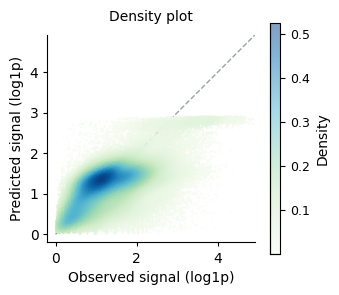

In [12]:
from epizoo.metrics.correlations import pearson_corr_log
from epizoo.visualization.density import plot_density_scatter

# Compute PCC between preds and targets
pcc = pearson_corr_log(preds, targets)
print(f"PCC between preds and targets: {pcc:.4f}")

# Density plot between preds and targets
plot_density_scatter(
    preds,
    targets,
    title="Density plot",
    figsize=(3,3),
)

## Step 6: Compute attribution scores

We use the `run_seq_attribution` function to compute attribution scores for a given  sequence using the trained EpiZoo model. The attribution scores quantify the contribution of individual nucleotides.

In this demo, we evaluate a representative enhancer region **AiE2428m** in the context of the **SstChodl** cell type. This enhancer is located at **chr13:92952861-92953624** in the mouse genome, and its DNA sequence is extracted from the **mm10** reference genome. The extracted sequence is then used as input for attribution analysis.

In [13]:
# Get the sequence
sequence = extract_dna_sequences(fasta_path=genome_file_path, regions=['chr13:92952861-92953624'])[0]
print(f"DNA sequence of AiE2428m: {sequence}")

Extracting DNA sequences: 100%|██████████| 1/1 [00:00<00:00, 7194.35it/s]

DNA sequence of AiE2428m: TCATTTATTTTCCTGTAAATGCTTCTATTGCTAACCAGGCCTTGGCCATTTTTCCCATGGGAAATGGAGTTGTTGGCTTCCCCTGGTTCCTGTTCACCATCCAGGAAGTCGAATAAATAATGACCGTAGCCCATACTGGTGGGATGGATACAGGAGGAGGACTGAAAGCAGGAGAATATCAAACCCATCAAAAATCACCGAGATCAGTGCAAAGACTGAAGCAGAAAGACACAGCCTCTAAATAGGAGCGGCCTTAATGAAAGTGCATCACCTCAGAGCCAACATGAAGTCTGCAGATGGGATGCACCTGCCTCCTGAGAACCTCACAGAGGGAAATCAAGCATCAGAACCCAGAATGGAAGCAGAAAACCCCCAATCAGACTCCTCGGAGACACTTCAGAAAAGGAACTCTCAGCTTGCAAAACAACAGGTGCATCTCTAAAGAGATGTGGCTCCTGCCCCCACCCCATACCACCGCACCCTGAGATTGCAGCACTGCTCTGAACTCTCCAATCAAGCCTCTTTCTTTGGTCACTCTTAAAGTGGTTGGTTTCCAGCACTAACCCTCACTCCTCCACCGAAATGAAATCTGCTAGCTTTGGCTGATGTTTAAACAGCTTCAATCTCTGGGGTCTTTTGTGAGAGAGGATAATTTTAACACTGGTGATAAACCCACCAGAATTTCCAGGTGAGAGGAGAAGCCTAGTGGAGCCTTTATCCAGCTGTTGAAGACAGGACCTGGGAACTCTTGGGACAAAGACAT


(<Figure size 3000x200 with 1 Axes>,
 <Axes: xlabel='Sequence position', ylabel='Contribution score'>,
             A         C         G         T
 0    0.000000  0.000000  0.000000 -0.045710
 1    0.000000 -0.040051  0.000000  0.000000
 2   -0.014630  0.000000  0.000000  0.000000
 3    0.000000  0.000000  0.000000  0.027284
 4    0.000000  0.000000  0.000000  0.052705
 ..        ...       ...       ...       ...
 758  0.000000  0.000000 -0.000094  0.000000
 759  0.000042  0.000000  0.000000  0.000000
 760  0.000000 -0.000019  0.000000  0.000000
 761 -0.000424  0.000000  0.000000  0.000000
 762  0.000000  0.000000  0.000000 -0.001015
 
 [763 rows x 4 columns])

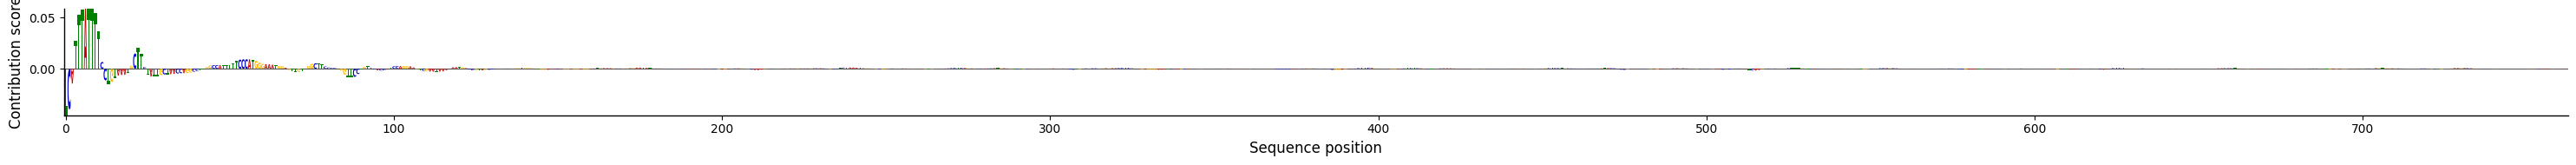

In [14]:
from epizoo.inference.seq import run_seq_attribution
from epizoo.visualization.attribution import plot_attribution_logo

results = run_seq_attribution(
    trained_model,
    tokenizer=train_dataset.tokenizer,
    sequence=sequence,
    target_cell_type='SstChodl',
    cell_type_names=sorted(np.unique(cell_types)),
    device=device,
)

plot_attribution_logo(
    sequence=sequence,
    scores=results['scores'],
    figsize=(30, 2),
)